In [1]:
# Load the IMDB Dataset
from tensorflow.keras.datasets import imdb
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Preprocess the Data
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

In [4]:
# Vectorize the training and test data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [5]:
# Convert labels to numpy arrays
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [6]:
# Split the training data into training and validation sets
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [7]:
# Build and Train Multiple Models

# Model 1: Baseline (2 hidden layers, 16 units)
model_baseline = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_baseline.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_baseline = model_baseline.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.7011 - loss: 0.6042 - val_accuracy: 0.8628 - val_loss: 0.4023
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8884 - loss: 0.3496 - val_accuracy: 0.8809 - val_loss: 0.3234
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9213 - loss: 0.2504 - val_accuracy: 0.8799 - val_loss: 0.3014
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9375 - loss: 0.1971 - val_accuracy: 0.8892 - val_loss: 0.2762
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9496 - loss: 0.1596 - val_accuracy: 0.8877 - val_loss: 0.2808
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9629 - loss: 0.1307 - val_accuracy: 0.8846 - val_loss: 0.2913
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9680 - loss: 0.1140 - val_accuracy: 0.8828 - val_loss: 0.3164
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9742 - loss: 0.0964 - val_accuracy: 0.8825 - v

In [8]:
# Model 2: 1 Hidden Layer
model_1_layer = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_1_layer.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_1_layer = model_1_layer.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.6980 - loss: 0.5894 - val_accuracy: 0.8402 - val_loss: 0.4239
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8904 - loss: 0.3589 - val_accuracy: 0.8799 - val_loss: 0.3342
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9134 - loss: 0.2779 - val_accuracy: 0.8871 - val_loss: 0.3010
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9275 - loss: 0.2288 - val_accuracy: 0.8860 - val_loss: 0.2887
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9343 - loss: 0.2059 - val_accuracy: 0.8854 - val_loss: 0.2843
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9485 - loss: 0.1763 - val_accuracy: 0.8841 - val_loss: 0.2898
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9509 - loss: 0.1593 - val_accuracy: 0.8868 - val_loss: 0.2754
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9550 - loss: 0.1449 - val_accuracy: 0.8858 - v

In [9]:
# Model 3: 3 Hidden Layers
model_3_layers = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_3_layers.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_3_layers = model_3_layers.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.6306 - loss: 0.6390 - val_accuracy: 0.8381 - val_loss: 0.4728
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8761 - loss: 0.4153 - val_accuracy: 0.8807 - val_loss: 0.3474
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9113 - loss: 0.2870 - val_accuracy: 0.8802 - val_loss: 0.3095
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9326 - loss: 0.2181 - val_accuracy: 0.8876 - val_loss: 0.2828
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9473 - loss: 0.1735 - val_accuracy: 0.8876 - val_loss: 0.2785
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9560 - loss: 0.1446 - val_accuracy: 0.8875 - val_loss: 0.2851
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9658 - loss: 0.1171 - val_accuracy: 0.8737 - val_loss: 0.3276
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9685 - loss: 0.1120 - val_accuracy: 0.8802 - v

In [10]:
# Model 4: 32 Hidden Units
model_32_units = keras.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_32_units.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_32_units = model_32_units.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.6927 - loss: 0.5939 - val_accuracy: 0.8632 - val_loss: 0.3671
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8784 - loss: 0.3285 - val_accuracy: 0.8682 - val_loss: 0.3222
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9183 - loss: 0.2331 - val_accuracy: 0.8858 - val_loss: 0.2827
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9408 - loss: 0.1796 - val_accuracy: 0.8867 - val_loss: 0.2762
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9514 - loss: 0.1489 - val_accuracy: 0.8855 - val_loss: 0.2833
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9604 - loss: 0.1237 - val_accuracy: 0.8767 - val_loss: 0.3372
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9702 - loss: 0.1020 - val_accuracy: 0.8799 - val_loss: 0.3428
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9756 - loss: 0.0861 - val_accuracy: 0.8750 - v

In [11]:
# Model 5: 64 Hidden Units
model_64_units = keras.Sequential([
    layers.Dense(64, activation="relu"),  # First hidden layer with 64 units
    layers.Dense(64, activation="relu"),  # Second hidden layer with 64 units
    layers.Dense(1, activation="sigmoid")  # Output layer
])

# Compile the model
model_64_units.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

# Train the model
history_64_units = model_64_units.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.6990 - loss: 0.5767 - val_accuracy: 0.7824 - val_loss: 0.4592
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.8798 - loss: 0.3201 - val_accuracy: 0.8867 - val_loss: 0.2858
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9170 - loss: 0.2262 - val_accuracy: 0.8892 - val_loss: 0.2751
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9408 - loss: 0.1772 - val_accuracy: 0.8889 - val_loss: 0.2793
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9512 - loss: 0.1430 - val_accuracy: 0.8799 - val_loss: 0.3196
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9462 - loss: 0.1392 - val_accuracy: 0.8833 - val_loss: 0.3042
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.9717 - loss: 0.0907 - val_accuracy: 0.8823 - val_loss: 0.3139
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9810 - loss: 0.0708 - val_accuracy: 0.8783 - 

In [12]:
# Model 6: MSE Loss Function
model_mse = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_mse.compile(optimizer="rmsprop", loss="mse", metrics=["accuracy"])
history_mse = model_mse.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.5775 - loss: 0.2343 - val_accuracy: 0.7319 - val_loss: 0.1853
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8333 - loss: 0.1644 - val_accuracy: 0.8728 - val_loss: 0.1328
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9000 - loss: 0.1133 - val_accuracy: 0.8797 - val_loss: 0.1052
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9191 - loss: 0.0816 - val_accuracy: 0.8863 - val_loss: 0.0929
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9388 - loss: 0.0628 - val_accuracy: 0.8860 - val_loss: 0.0892
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9486 - loss: 0.0535 - val_accuracy: 0.8859 - val_loss: 0.0868
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9572 - loss: 0.0447 - val_accuracy: 0.8728 - val_loss: 0.0929
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9606 - loss: 0.0403 - val_accuracy: 0.8825 - 

In [13]:
# Model 7: tanh Activation
model_tanh = keras.Sequential([
    layers.Dense(16, activation="tanh"),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])
model_tanh.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_tanh = model_tanh.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.7074 - loss: 0.5706 - val_accuracy: 0.8690 - val_loss: 0.3655
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8985 - loss: 0.3081 - val_accuracy: 0.8728 - val_loss: 0.3121
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9246 - loss: 0.2192 - val_accuracy: 0.8863 - val_loss: 0.2765
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9474 - loss: 0.1583 - val_accuracy: 0.8879 - val_loss: 0.2767
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9580 - loss: 0.1292 - val_accuracy: 0.8860 - val_loss: 0.2947
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9690 - loss: 0.1021 - val_accuracy: 0.8813 - val_loss: 0.3284
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9664 - loss: 0.0951 - val_accuracy: 0.8803 - val_loss: 0.3524
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9820 - loss: 0.0635 - val_accuracy: 0.8767 - v

In [13]:
from tensorflow.keras import regularizers

# Model 8: L2 Regularization
model_l2 = keras.Sequential([
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation="sigmoid")
])
model_l2.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_l2 = model_l2.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.6712 - loss: 0.6724 - val_accuracy: 0.8625 - val_loss: 0.4827
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8843 - loss: 0.4307 - val_accuracy: 0.8796 - val_loss: 0.3890
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9133 - loss: 0.3331 - val_accuracy: 0.8863 - val_loss: 0.3500
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9273 - loss: 0.2807 - val_accuracy: 0.8778 - val_loss: 0.3513
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9311 - loss: 0.2581 - val_accuracy: 0.8772 - val_loss: 0.3536
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9466 - loss: 0.2262 - val_accuracy: 0.8843 - val_loss: 0.3407
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9515 - loss: 0.2142 - val_accuracy: 0.8801 - val_loss: 0.3489
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9536 - loss: 0.2054 - val_accuracy: 0.8859 - v

In [14]:
# Model 9: Dropout
model_dropout = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
model_dropout.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_dropout = model_dropout.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.5744 - loss: 0.6710 - val_accuracy: 0.8357 - val_loss: 0.5574
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7446 - loss: 0.5539 - val_accuracy: 0.8622 - val_loss: 0.4501
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8081 - loss: 0.4698 - val_accuracy: 0.8769 - val_loss: 0.3637
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8430 - loss: 0.3966 - val_accuracy: 0.8852 - val_loss: 0.3207
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8734 - loss: 0.3485 - val_accuracy: 0.8876 - val_loss: 0.2973
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8938 - loss: 0.3079 - val_accuracy: 0.8773 - val_loss: 0.2944
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9064 - loss: 0.2710 - val_accuracy: 0.8869 - val_loss: 0.2950
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9170 - loss: 0.2413 - val_accuracy: 0.8894 - v

In [28]:
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.datasets import imdb
import numpy as np

# Load and preprocess the IMDB dataset
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

# Split the data into training and validation sets
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Model 1: Baseline (2 layers, 16 units)
model_baseline = models.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_baseline.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_baseline = model_baseline.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 2: 1 Hidden Layer
model_1_layer = models.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_1_layer.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_1_layer = model_1_layer.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 3: 3 Hidden Layers
model_3_layers = models.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_3_layers.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_3_layers = model_3_layers.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 4: 32 Hidden Units
model_32_units = models.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_32_units.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_32_units = model_32_units.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 5: 64 Hidden Units
model_64_units = models.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_64_units.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_64_units = model_64_units.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 6: MSE Loss Function
model_mse = models.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_mse.compile(optimizer="rmsprop", loss="mse", metrics=["accuracy"])
history_mse = model_mse.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 7: tanh Activation
model_tanh = models.Sequential([
    layers.Dense(16, activation="tanh"),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])
model_tanh.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_tanh = model_tanh.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 8: L2 Regularization
model_l2 = models.Sequential([
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation="sigmoid")
])
model_l2.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_l2 = model_l2.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

# Model 9: Dropout
model_dropout = models.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
model_dropout.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_dropout = model_dropout.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.6920 - loss: 0.6209 - val_accuracy: 0.8204 - val_loss: 0.4490
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.8821 - loss: 0.3729 - val_accuracy: 0.8606 - val_loss: 0.3534
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9129 - loss: 0.2713 - val_accuracy: 0.8867 - val_loss: 0.2919
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9304 - loss: 0.2173 - val_accuracy: 0.8877 - val_loss: 0.2828
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9443 - loss: 0.1726 - val_accuracy: 0.8851 - val_loss: 0.2848
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9525 - loss: 0.1504 - val_accuracy: 0.8874 - val_loss: 0.2901
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9602 - loss: 0.1286 - val_accuracy: 0.8782 - val_loss: 0.3053
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9688 - loss: 0.1102 - val_accuracy: 0.8632 - 

In [29]:
import pandas as pd

# Define the data for the table
data = {
    "Model": ["Model 1", "Model 2", "Model 3", "Model 4", "Model 5", "Model 6", "Model 7", "Model 8", "Model 9"],
    "Configuration": [
        "Baseline (2 layers, 16 units)",
        "1 Hidden Layer",
        "3 Hidden Layers",
        "32 Hidden Units",
        "64 Hidden Units",
        "MSE Loss Function",
        "tanh Activation",
        "L2 Regularization",
        "Dropout"
    ],
    "Training Accuracy": [
        max(history_baseline.history["accuracy"]),
        max(history_1_layer.history["accuracy"]),
        max(history_3_layers.history["accuracy"]),
        max(history_32_units.history["accuracy"]),
        max(history_64_units.history["accuracy"]),
        max(history_mse.history["accuracy"]),
        max(history_tanh.history["accuracy"]),
        max(history_l2.history["accuracy"]),
        max(history_dropout.history["accuracy"])
    ],
    "Validation Accuracy": [
        max(history_baseline.history["val_accuracy"]),
        max(history_1_layer.history["val_accuracy"]),
        max(history_3_layers.history["val_accuracy"]),
        max(history_32_units.history["val_accuracy"]),
        max(history_64_units.history["val_accuracy"]),
        max(history_mse.history["val_accuracy"]),
        max(history_tanh.history["val_accuracy"]),
        max(history_l2.history["val_accuracy"]),
        max(history_dropout.history["val_accuracy"])
    ],
    "Training Loss": [
        min(history_baseline.history["loss"]),
        min(history_1_layer.history["loss"]),
        min(history_3_layers.history["loss"]),
        min(history_32_units.history["loss"]),
        min(history_64_units.history["loss"]),
        min(history_mse.history["loss"]),
        min(history_tanh.history["loss"]),
        min(history_l2.history["loss"]),
        min(history_dropout.history["loss"])
    ],
    "Validation Loss": [
        min(history_baseline.history["val_loss"]),
        min(history_1_layer.history["val_loss"]),
        min(history_3_layers.history["val_loss"]),
        min(history_32_units.history["val_loss"]),
        min(history_64_units.history["val_loss"]),
        min(history_mse.history["val_loss"]),
        min(history_tanh.history["val_loss"]),
        min(history_l2.history["val_loss"]),
        min(history_dropout.history["val_loss"])
    ]
}

# Create a DataFrame
results_table = pd.DataFrame(data)

# Display the table
print(results_table)

     Model                  Configuration  Training Accuracy  \
0  Model 1  Baseline (2 layers, 16 units)           0.997733   
1  Model 2                 1 Hidden Layer           0.990133   
2  Model 3                3 Hidden Layers           0.999867   
3  Model 4                32 Hidden Units           0.999867   
4  Model 5                64 Hidden Units           1.000000   
5  Model 6              MSE Loss Function           0.990200   
6  Model 7                tanh Activation           0.999467   
7  Model 8              L2 Regularization           0.983933   
8  Model 9                        Dropout           0.976933   

   Validation Accuracy  Training Loss  Validation Loss  
0               0.8877       0.022313         0.282775  
1               0.8908       0.055247         0.274969  
2               0.8877       0.004182         0.280031  
3               0.8904       0.005357         0.276366  
4               0.8893       0.002308         0.275572  
5               0

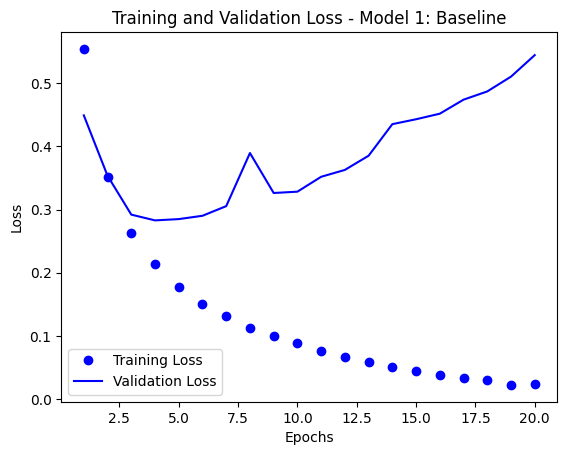

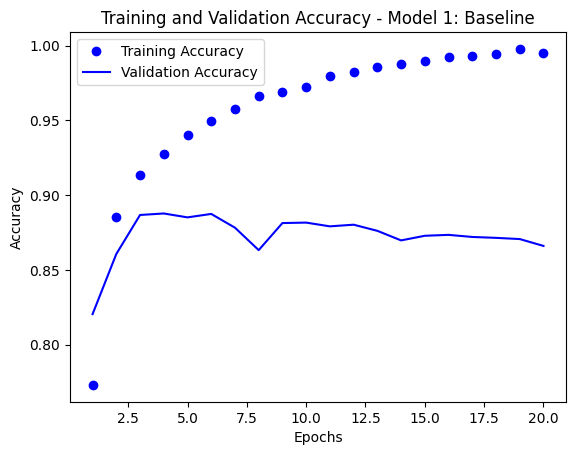

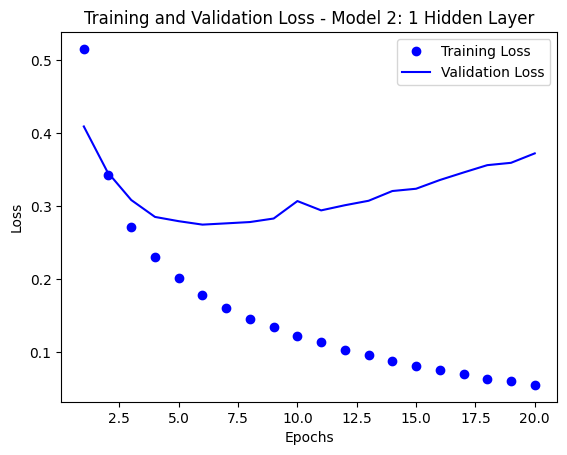

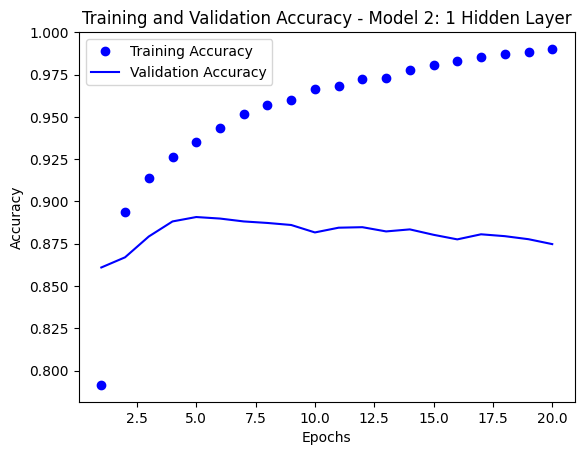

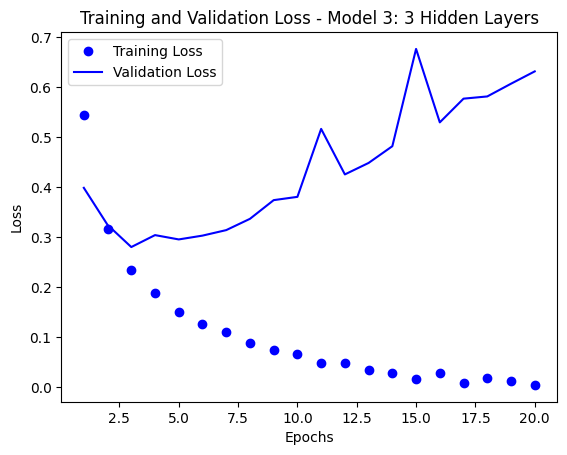

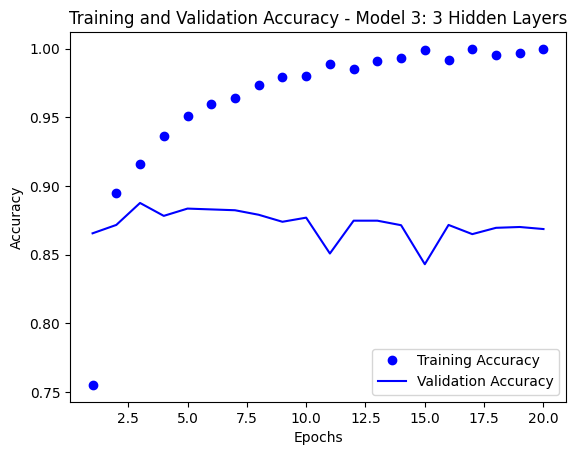

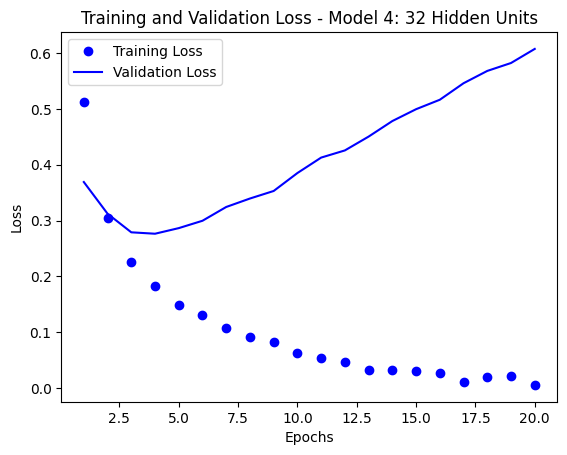

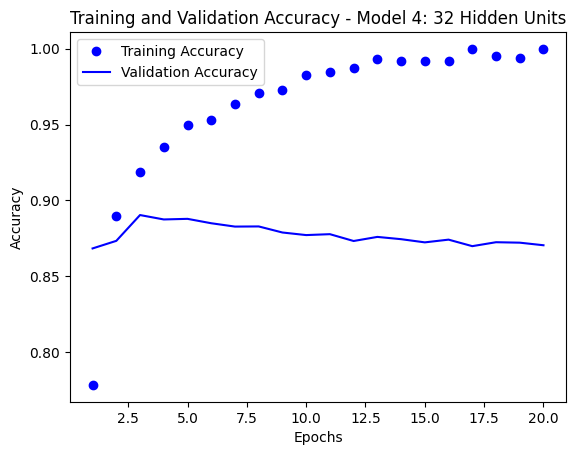

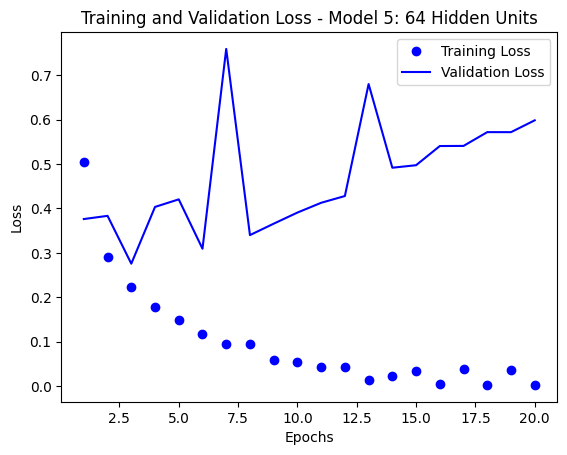

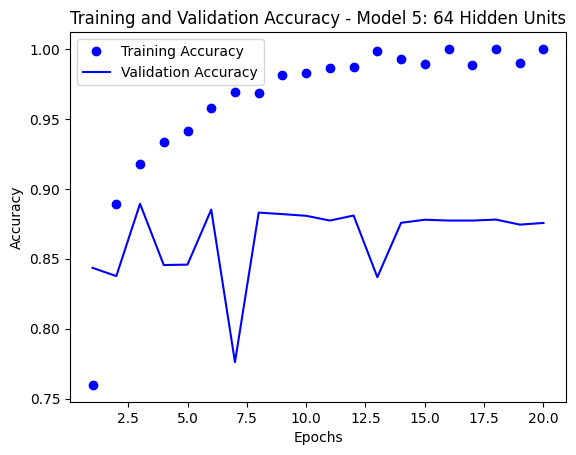

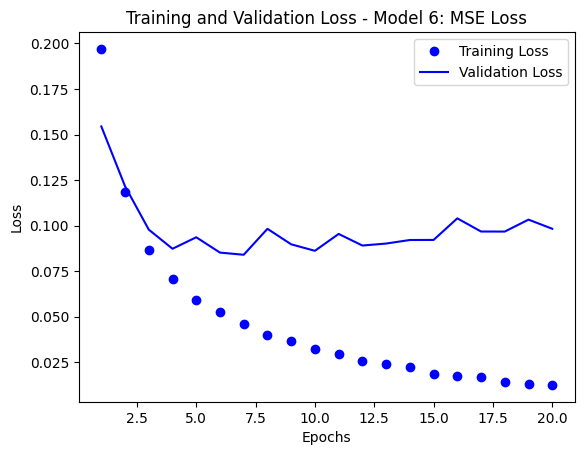

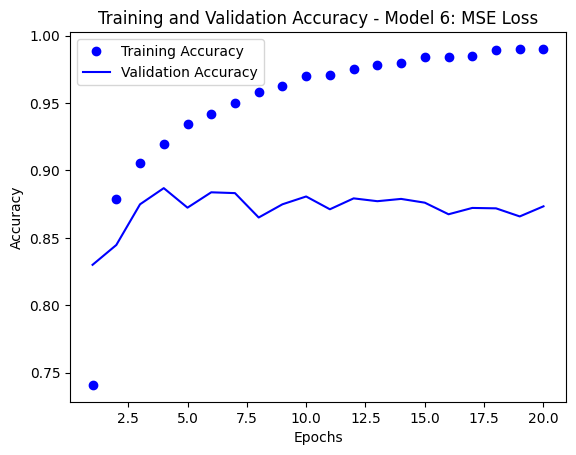

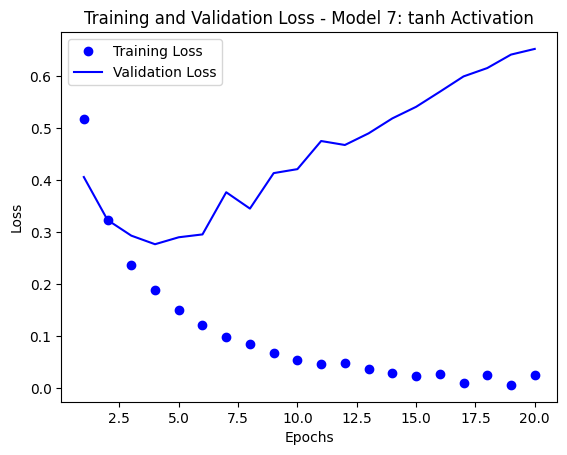

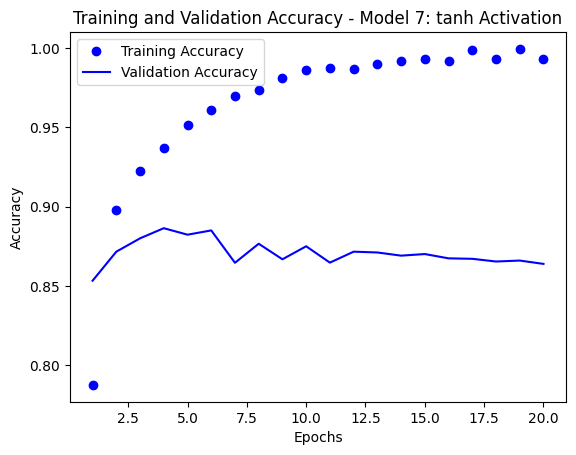

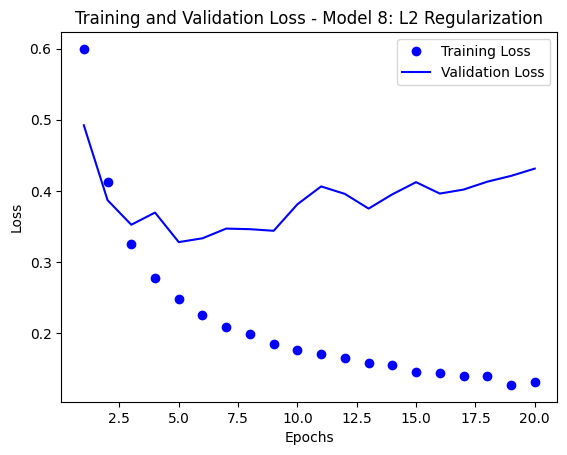

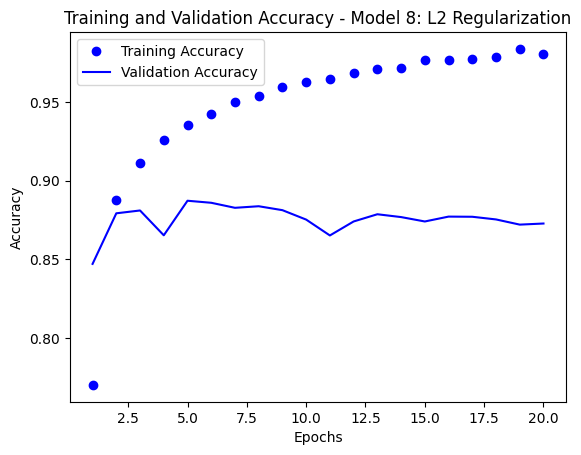

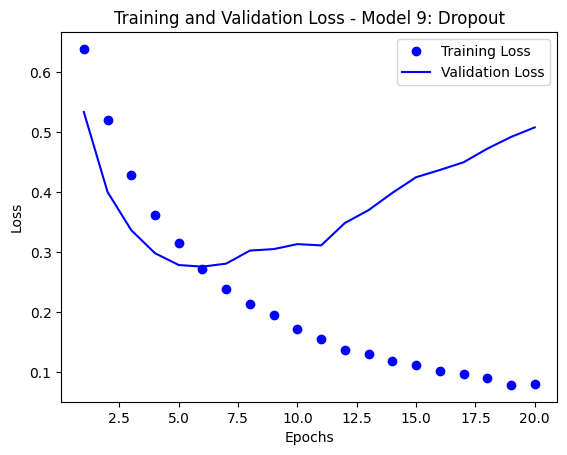

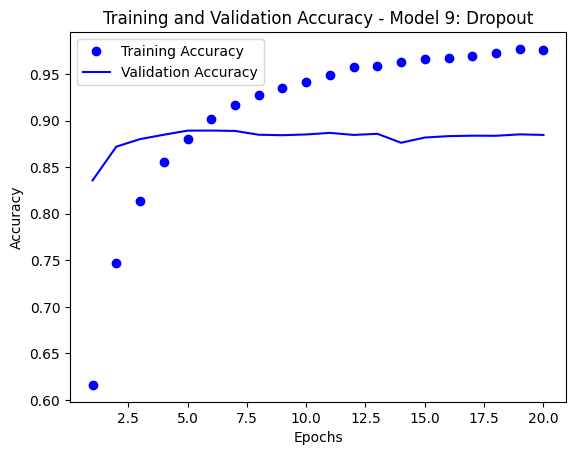

In [42]:
import matplotlib.pyplot as plt

# Define a list of history objects for each model
histories = [history_baseline, history_1_layer, history_3_layers, history_32_units,
             history_64_units, history_mse, history_tanh, history_l2, history_dropout]

# Define a list of model names for plot titles
model_names = ["Model 1: Baseline", "Model 2: 1 Hidden Layer", "Model 3: 3 Hidden Layers",
               "Model 4: 32 Hidden Units", "Model 5: 64 Hidden Units", "Model 6: MSE Loss",
               "Model 7: tanh Activation", "Model 8: L2 Regularization", "Model 9: Dropout"]

# Loop through each model and plot loss and accuracy
for i, history in enumerate(histories):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)

    # Plot Loss
    plt.plot(epochs, loss_values, "bo", label="Training Loss")
    plt.plot(epochs, val_loss_values, "b", label="Validation Loss")
    plt.title(f"Training and Validation Loss - {model_names[i]}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Plot Accuracy
    acc_values = history_dict["accuracy"]
    val_acc_values = history_dict["val_accuracy"]

    plt.plot(epochs, acc_values, "bo", label="Training Accuracy")
    plt.plot(epochs, val_acc_values, "b", label="Validation Accuracy")
    plt.title(f"Training and Validation Accuracy - {model_names[i]}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()